# ARTI404 – Image Processing | Lab 3: Image Manipulations using OpenCV

**Student name:** Maan A Alghamdi
**Student ID:** 2240001433

**Outcomes:**
- Explain how digital images are represented and manipulated in a computer.
- Apply some geometric transformations to the images.

**Tools:** Python 3, Jupyter, OpenCV (plus NumPy and Matplotlib).

**Images used** (from the `images` folder):
- `fruits.jpg`: a bright color photo, used for Steps 1–4.
- `building.jpg`: has straight lines (so rotation and shear are easy to see) and is quite dark (so the log and gamma transforms have a visible effect), used for Tasks 1 and 2.

Contents: Steps 1–4 (code from the manual) → Task 1 (geometric transformations) → Task 2 (intensity transformations).

## Setup: libraries, image folder, and helper functions

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'jpeg'   # keeps the notebook file small

# The manual keeps the pictures in an 'images' folder next to the notebook.
IMG_DIR = 'images'
for candidate in ['images', '../images',
                  os.path.join(os.path.expanduser('~'), 'OneDrive', 'سطح المكتب', 'images')]:
    if os.path.isdir(candidate):
        IMG_DIR = candidate
        break

print('OpenCV version:', cv2.__version__)
print('Image folder  :', os.path.abspath(IMG_DIR))
print('Files         :', sorted(os.listdir(IMG_DIR)))

OpenCV version: 5.0.0
Image folder  : c:\Users\M3n_a\OneDrive\سطح المكتب\images
Files         : ['A.png', 'B.png', 'building.jpg', 'cameraman.tif', 'fruits.jpg', 'lena_gray_256.tif']


**Why the helpers below?**
- `imread` / `imwrite` call `cv2.imread` / `cv2.imwrite` exactly like the manual. On Windows, OpenCV can't open paths that contain non-English characters (like an Arabic folder name), so they fall back to `cv2.imdecode` / `cv2.imencode` in that case.
- `show` replaces `cv2.imshow`. In Jupyter, `cv2.imshow` opens a separate window and can freeze the kernel, and its output isn't saved in the notebook. `show` draws the images inline with Matplotlib instead. OpenCV stores color as **BGR**, while Matplotlib expects **RGB**, so the channels are swapped before drawing.

In [2]:
def imread(name, flags=cv2.IMREAD_COLOR):
    """Read an image from IMG_DIR (cv2.imread, with a fallback for non-English paths)."""
    path = os.path.join(IMG_DIR, name)
    img = cv2.imread(path, flags)
    if img is None:
        img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), flags)
    if img is None:
        raise FileNotFoundError(path)
    return img


def imwrite(name, img):
    """Save an image into IMG_DIR (cv2.imwrite, with a fallback for non-English paths)."""
    path = os.path.join(IMG_DIR, name)
    try:
        ok = cv2.imwrite(path, img)
    except cv2.error:
        ok = False
    if not ok:
        ok, buf = cv2.imencode(os.path.splitext(path)[1], img)
        buf.tofile(path)
    return path


def show(images, titles, cols=None, size=4.5, axis=False):
    """Inline replacement for cv2.imshow. Color images are converted BGR -> RGB."""
    cols = cols or len(images)
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows * 0.85))
    axes = np.atleast_1d(axes).ravel()
    for ax, im, title in zip(axes, images, titles):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        if not axis:
            ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Step 1: Read an image using the OpenCV library

`cv2.imread` returns the image as a **NumPy array** (`numpy.ndarray`). A color image has the shape `(rows, columns, 3)`. Each pixel holds 3 numbers from 0 to 255, in the order **Blue, Green, Red**. The data type is `uint8` (unsigned 8-bit integer).

The manual's version, which opens a separate window when run as a script:
```python
img = cv2.imread('./images/input.jpg')
cv2.imshow('Input image', img)
cv2.waitKey()
```

type  : <class 'numpy.ndarray'>
shape : (360, 532, 3) -> (rows, columns, channels)
dtype : uint8
pixel at row 100, col 100 (B, G, R): [  0 192 250]


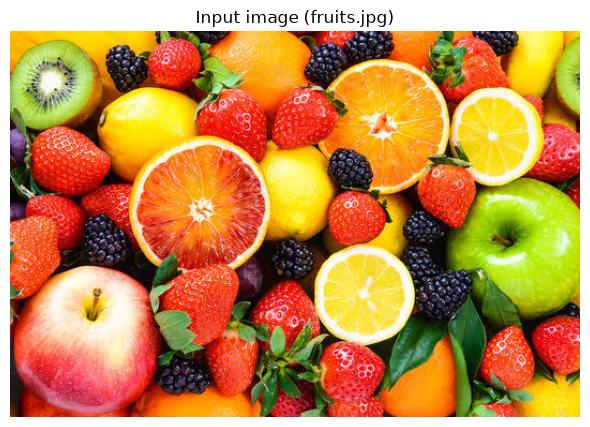

In [3]:
img = imread('fruits.jpg')          # same as cv2.imread('./images/fruits.jpg')

print('type  :', type(img))
print('shape :', img.shape, '-> (rows, columns, channels)')
print('dtype :', img.dtype)
print('pixel at row 100, col 100 (B, G, R):', img[100, 100])

show([img], ['Input image (fruits.jpg)'], size=6)

## Step 2: Load an image in grayscale

Passing `cv2.IMREAD_GRAYSCALE` converts the image to grayscale **while it is being read**. The result has a single channel: shape `(rows, columns)`, one brightness value from 0 (black) to 255 (white) per pixel.

shape : (360, 532) -> (rows, columns), one channel only
pixel at row 100, col 100: 187


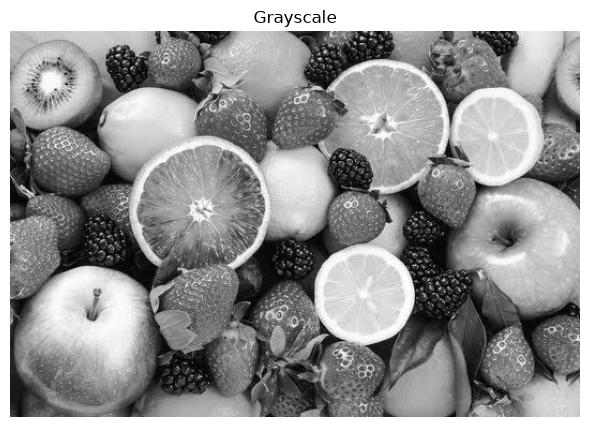

In [4]:
gray_img = imread('fruits.jpg', cv2.IMREAD_GRAYSCALE)   # cv2.imread('images/fruits.jpg', cv2.IMREAD_GRAYSCALE)

print('shape :', gray_img.shape, '-> (rows, columns), one channel only')
print('pixel at row 100, col 100:', gray_img[100, 100])

show([gray_img], ['Grayscale'], size=6)

## Step 3: Save an image

`cv2.imwrite` writes the array to disk. The file format is chosen from the extension (`.jpg`, `.png`, ...). The file is read back below to confirm it was saved.

Saved to: c:\Users\M3n_a\OneDrive\سطح المكتب\images\output.jpg
Read back, shape: (360, 532)


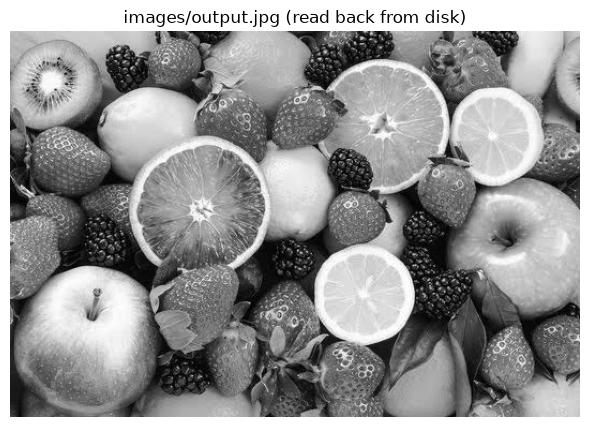

In [5]:
out_path = imwrite('output.jpg', gray_img)     # cv2.imwrite('images/output.jpg', gray_img)
print('Saved to:', os.path.abspath(out_path))

saved = imread('output.jpg', cv2.IMREAD_GRAYSCALE)
print('Read back, shape:', saved.shape)
show([saved], ['images/output.jpg (read back from disk)'], size=6)

## Step 4: Convert an image to different color spaces

### 4.1 BGR → Grayscale with `cv2.cvtColor`
Use this when the image has already been read in color.

color shape: (360, 532, 3)  -> gray shape: (360, 532)


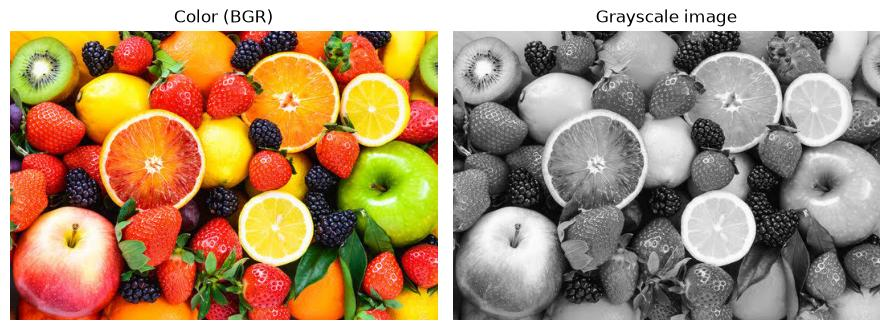

In [6]:
img = imread('fruits.jpg')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print('color shape:', img.shape, ' -> gray shape:', gray_img.shape)
show([img, gray_img], ['Color (BGR)', 'Grayscale image'])

### 4.2 List the available color-conversion flags
The manual's `print [x for x in dir(cv2) if x.startswith('COLOR_')]` is Python 2 syntax. In Python 3, `print` is a function and needs parentheses. The full list is very long, so only the count and the first 20 flags are printed.

In [7]:
flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print('Number of COLOR_ flags:', len(flags))
print(flags[:20])

Number of COLOR_ flags: 374
['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA']


### 4.3 BGR → YUV and its three channels
YUV is a color model used in television:
- **Y**: brightness (luma). It looks like a grayscale version of the image.
- **U**: blue projection (blue minus brightness).
- **V**: red projection (red minus brightness).

In U and V, gray (about 128) means "no color". Brighter or darker areas show where blue (U) or red (V) is strong. The red and orange fruits show up clearly in the V channel.

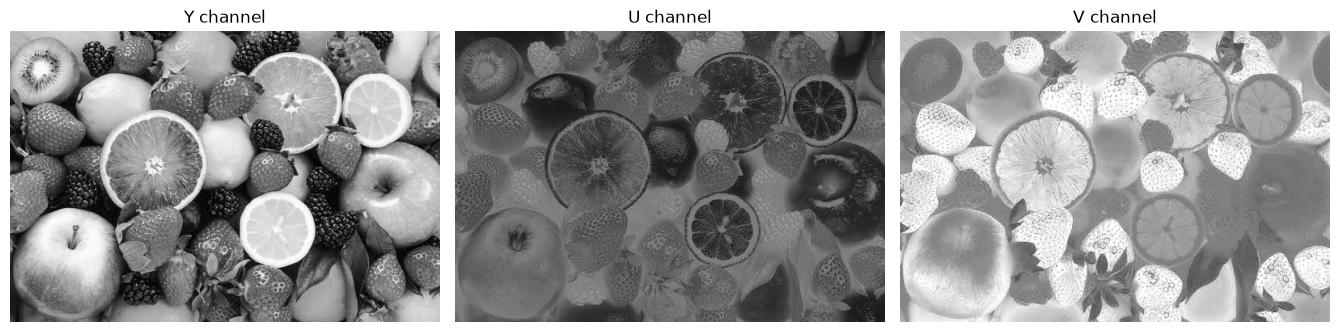

In [8]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

show([yuv_img[:, :, 0], yuv_img[:, :, 1], yuv_img[:, :, 2]],
     ['Y channel', 'U channel', 'V channel'])

# Assessment

## Task 1: Geometric transformations
Geometric transformations move pixels to new positions without changing their values. Every transformation here is applied to `building.jpg`, because its straight edges make the effect easy to see.

building.jpg shape: (459, 612, 3)


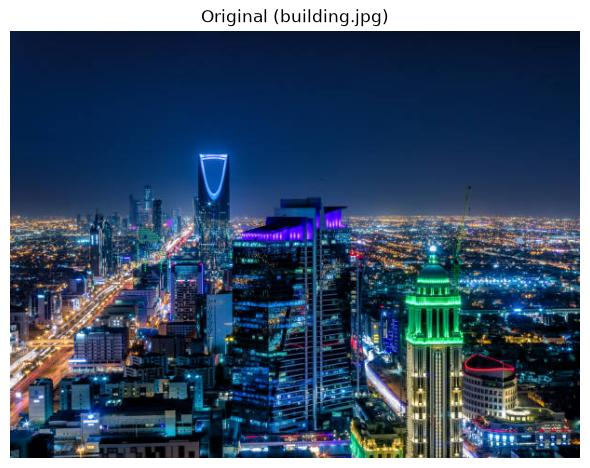

In [9]:
building = imread('building.jpg')
h, w = building.shape[:2]
print('building.jpg shape:', building.shape)
show([building], ['Original (building.jpg)'], size=6)

### 1.1 Increase the size of the image (scaling)
`cv2.resize` with a scale factor of **2** in both directions doubles the width and the height. The new in-between pixels are calculated by **interpolation**:
- `INTER_NEAREST` copies the closest pixel. It is fast but gives a blocky result.
- `INTER_CUBIC` uses the 4×4 neighbourhood of pixels. It is smoother and better for enlarging.

Matplotlib scales every picture to fit its box, so the axes show pixel coordinates to prove the size really doubled. The zoomed crops underneath compare the two interpolation methods.

original : (459, 612, 3)
enlarged : (918, 1224, 3)


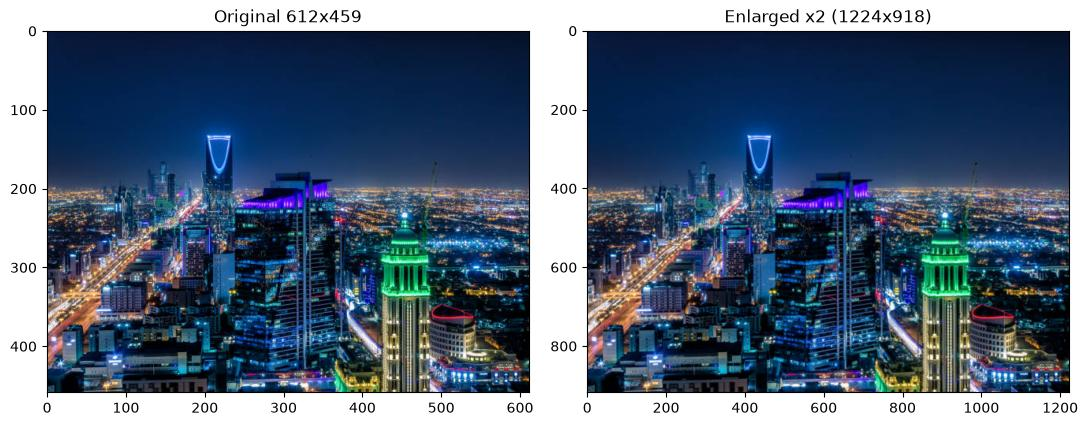

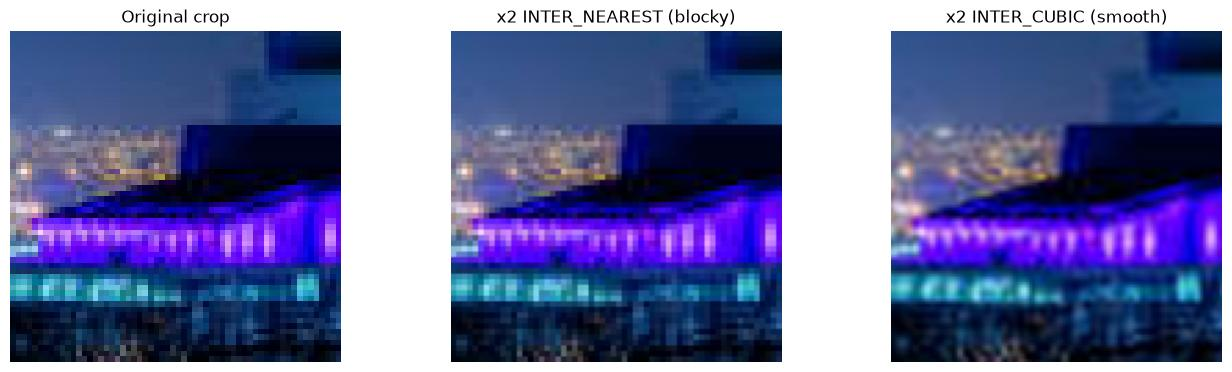

In [10]:
scale = 2
enlarged_cubic = cv2.resize(building, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
enlarged_nearest = cv2.resize(building, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)

print('original :', building.shape)
print('enlarged :', enlarged_cubic.shape)

show([building, enlarged_cubic],
     [f'Original {w}x{h}', f'Enlarged x{scale} ({enlarged_cubic.shape[1]}x{enlarged_cubic.shape[0]})'],
     axis=True, size=5.5)

# Same region, zoomed in: nearest-neighbour vs bicubic
y0, x0, s = 2 * h // 5, 2 * w // 5, 60
show([building[y0:y0 + s, x0:x0 + s],
      enlarged_nearest[scale * y0:scale * (y0 + s), scale * x0:scale * (x0 + s)],
      enlarged_cubic[scale * y0:scale * (y0 + s), scale * x0:scale * (x0 + s)]],
     ['Original crop', 'x2 INTER_NEAREST (blocky)', 'x2 INTER_CUBIC (smooth)'])

### 1.2 Rotate the image by 120 degrees
`cv2.getRotationMatrix2D(center, angle, scale)` builds a 2×3 affine matrix, and `cv2.warpAffine` applies it. In OpenCV, a **positive angle rotates counter-clockwise**.

$$M = \begin{bmatrix} \cos\theta & \sin\theta & (1-\cos\theta)c_x - \sin\theta\, c_y \\ -\sin\theta & \cos\theta & \sin\theta\, c_x + (1-\cos\theta)c_y \end{bmatrix}$$

If the output keeps the original size, the corners get cut off. `rotate_full` makes the output canvas big enough for the whole rotated image, $W' = h|\sin\theta| + w|\cos\theta|$ and $H' = h|\cos\theta| + w|\sin\theta|$, and shifts the result to the middle.

Rotation matrix (same canvas):
 [[-5.00000e-01  8.66000e-01  2.60247e+02]
 [-8.66000e-01 -5.00000e-01  6.09254e+02]]
cropped version : (459, 612, 3)
full version    : (760, 704, 3)


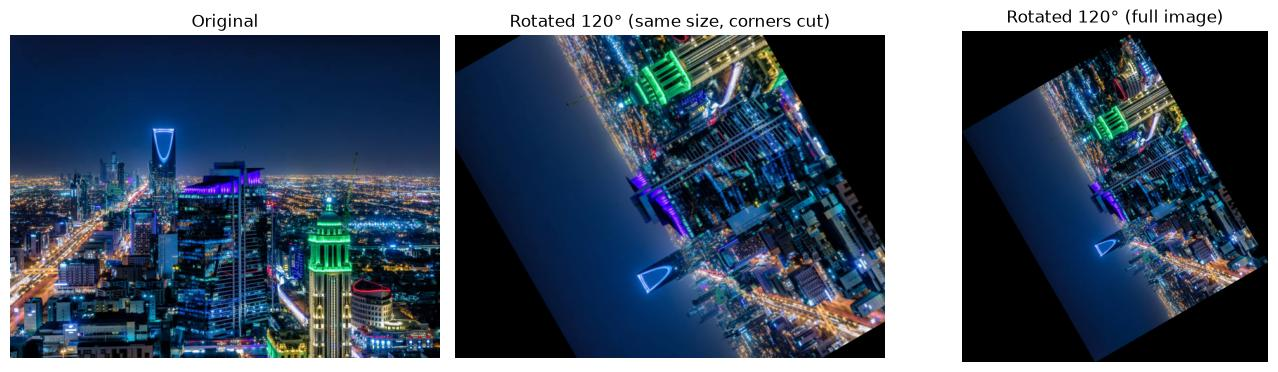

In [11]:
angle = 120

# (a) Same canvas size: the corners are cropped
M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
rotated_cropped = cv2.warpAffine(building, M, (w, h))


# (b) Bigger canvas so the whole image stays visible
def rotate_full(image, angle):
    h, w = image.shape[:2]
    cx, cy = w / 2, h / 2
    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(round(h * sin + w * cos))
    new_h = int(round(h * cos + w * sin))
    M[0, 2] += new_w / 2 - cx     # move the rotated image to the centre of the new canvas
    M[1, 2] += new_h / 2 - cy
    return cv2.warpAffine(image, M, (new_w, new_h))


rotated_full = rotate_full(building, angle)
print('Rotation matrix (same canvas):\n', np.round(M, 3))
print('cropped version :', rotated_cropped.shape)
print('full version    :', rotated_full.shape)

show([building, rotated_cropped, rotated_full],
     ['Original', f'Rotated {angle}° (same size, corners cut)', f'Rotated {angle}° (full image)'])

### 1.3 Shear the image
A shear slants the image, turning rectangles into parallelograms. It is an affine transformation:
- **Horizontal shear** (factor $sh_x$): $x' = x + sh_x \cdot y$, $y' = y$  →  $M = \begin{bmatrix}1 & sh_x & 0\\ 0 & 1 & 0\end{bmatrix}$
- **Vertical shear** (factor $sh_y$): $x' = x$, $y' = y + sh_y \cdot x$  →  $M = \begin{bmatrix}1 & 0 & 0\\ sh_y & 1 & 0\end{bmatrix}$

The output is widened (or made taller) by $sh \cdot h$ (or $sh \cdot w$) so that nothing is cut off.

horizontal shear: (459, 795, 3) | vertical shear: (642, 612, 3)


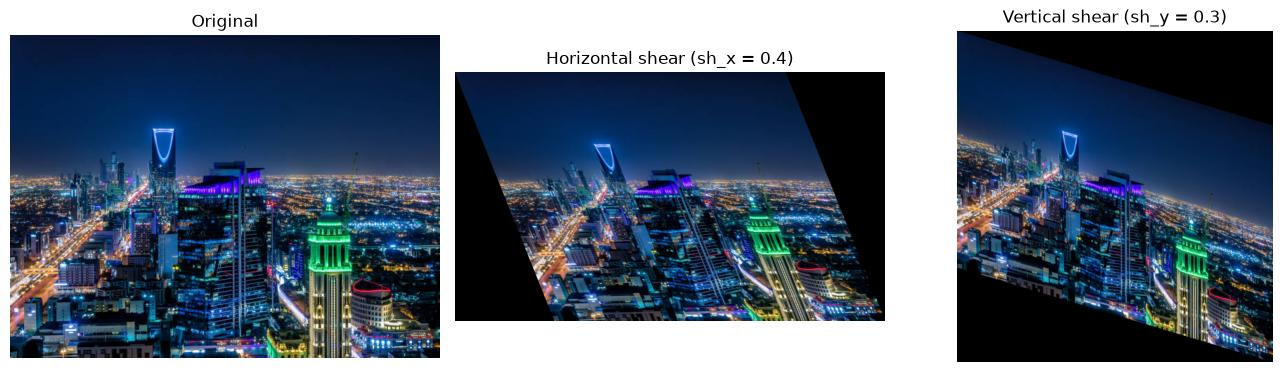

In [12]:
sh_x, sh_y = 0.4, 0.3

# Horizontal shear
M_x = np.float32([[1, sh_x, 0],
                  [0, 1,    0]])
sheared_x = cv2.warpAffine(building, M_x, (int(w + sh_x * h), h))

# Vertical shear
M_y = np.float32([[1,    0, 0],
                  [sh_y, 1, 0]])
sheared_y = cv2.warpAffine(building, M_y, (w, int(h + sh_y * w)))

print('horizontal shear:', sheared_x.shape, '| vertical shear:', sheared_y.shape)
show([building, sheared_x, sheared_y],
     ['Original', f'Horizontal shear (sh_x = {sh_x})', f'Vertical shear (sh_y = {sh_y})'])

## Task 2: Intensity transformations
Intensity transformations change pixel **values** but not their positions: every input level $r$ (0–255) is mapped to an output level $s = T(r)$. They are applied to the grayscale version of `building.jpg`. This photo is **dark** (most pixels are below 100), so it is a good test for transformations that bring out detail in dark areas.

To measure contrast, the **standard deviation of the pixel values** (RMS contrast) is used: the more spread out the gray levels, the higher the contrast.

min = 0 | max = 255 | mean = 55.7 | contrast (std) = 43.6


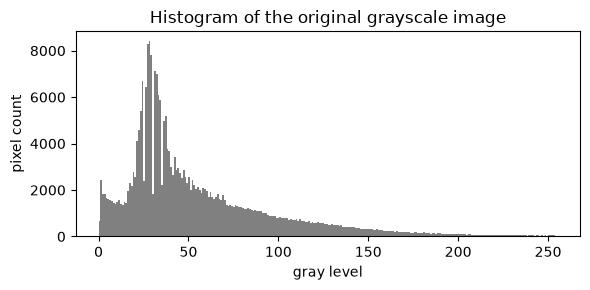

In [13]:
gray = cv2.cvtColor(building, cv2.COLOR_BGR2GRAY)
print('min =', gray.min(), '| max =', gray.max(),
      '| mean = %.1f' % gray.mean(), '| contrast (std) = %.1f' % gray.std())

plt.figure(figsize=(6, 3))
plt.hist(gray.ravel(), bins=256, range=(0, 255), color='gray')
plt.title('Histogram of the original grayscale image')
plt.xlabel('gray level'); plt.ylabel('pixel count')
plt.tight_layout(); plt.show()

### 2.1 Negative image
$$s = (L - 1) - r = 255 - r$$
Dark areas become bright and bright areas become dark. This helps show white or gray detail inside large dark regions.

pixel (100, 100): original = 32 -> negative = 223


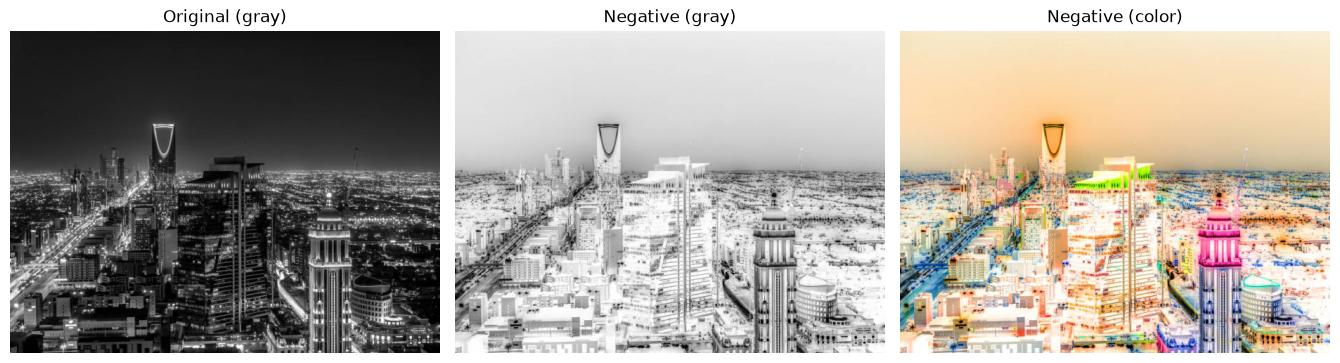

In [14]:
negative = 255 - gray          # same result as cv2.bitwise_not(gray)
color_negative = 255 - building  # also works on each color channel

print('pixel (100, 100): original =', gray[100, 100], '-> negative =', negative[100, 100])
show([gray, negative, color_negative], ['Original (gray)', 'Negative (gray)', 'Negative (color)'])

### 2.2 Log transformation
$$s = c \cdot \log(1 + r)$$
The log curve stretches the **dark** levels and compresses the bright ones, which suits this dark image.

**Choosing the constant $c$:** $c$ is set so that the brightest input pixel maps to 255, which uses the full output range without clipping:
$$c = \frac{255}{\log(1 + r_{max})}$$
With a larger $c$, many pixels go above 255 and are clipped to white. With a smaller $c$, the output never reaches white and the image looks dull. The comparison below shows both cases.

r_max = 255  ->  c = 255 / log(1 + 255) = 45.99
contrast (std): original = 43.6 | log (c = 46.0) = 38.8


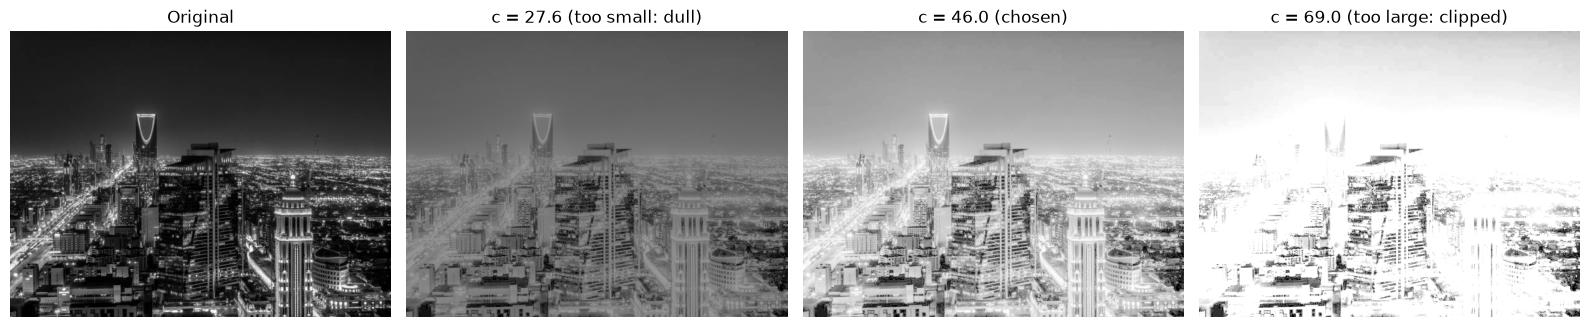

In [15]:
r = gray.astype(np.float64)
c = 255 / np.log(1 + r.max())
print('r_max = %d  ->  c = 255 / log(1 + %d) = %.2f' % (r.max(), r.max(), c))


def log_transform(img, c):
    s = c * np.log(1 + img.astype(np.float64))
    return np.clip(s, 0, 255).astype(np.uint8)


log_img = log_transform(gray, c)
log_small = log_transform(gray, c * 0.6)
log_large = log_transform(gray, c * 1.5)

print('contrast (std): original = %.1f | log (c = %.1f) = %.1f' % (gray.std(), c, log_img.std()))
show([gray, log_small, log_img, log_large],
     ['Original', f'c = {c * 0.6:.1f} (too small: dull)', f'c = {c:.1f} (chosen)', f'c = {c * 1.5:.1f} (too large: clipped)'], size=4)

**Result:** the log transform reveals the detail hidden in the dark streets and the sky. Its overall standard deviation is slightly *lower* than the original's, though, because the bright city lights get squeezed into a narrow range near white. That's why log is best for **revealing dark detail**, and the power law below is better for **increasing contrast**.

### 2.3 Power-law (gamma) transformation
$$s = 255 \cdot \left(\frac{r}{255}\right)^{\gamma}$$
- $\gamma < 1$ brightens the image and stretches the dark levels.
- $\gamma > 1$ darkens the image and stretches the bright levels.
- $\gamma = 1$ leaves the image unchanged.

**Choosing $\gamma$:** most of this image's pixels are in the dark range, so a $\gamma < 1$ is expected to spread them out. Instead of guessing, several values are tried and the one that gives the **highest contrast (standard deviation)** is picked.

 gamma | contrast (std)
   0.2 |   30.7
   0.3 |   37.3
   0.4 |   41.4
   0.5 |   43.7
   0.6 |   44.9
   0.7 |   45.3
   0.8 |   45.1
   1.0 |   43.6
   1.5 |   38.0
   2.0 |   32.6
   2.5 |   28.4

Chosen gamma = 0.7 (contrast 43.6 -> 45.3)


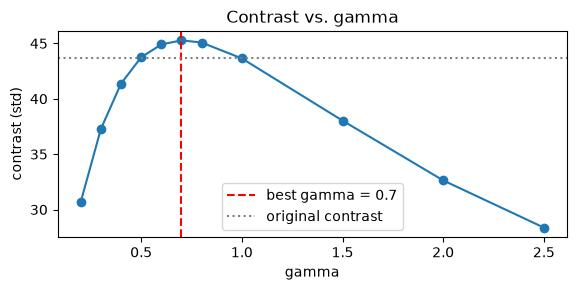

In [16]:
def gamma_transform(img, gamma):
    table = (255 * (np.arange(256) / 255.0) ** gamma).round().astype(np.uint8)   # lookup table for 0..255
    return cv2.LUT(img, table)


gammas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.5, 2.0, 2.5]
contrast = {g: gamma_transform(gray, g).std() for g in gammas}

print(' gamma | contrast (std)')
for g in gammas:
    print(f' {g:5.1f} | {contrast[g]:6.1f}')

best_gamma = max(contrast, key=contrast.get)
print(f'\nChosen gamma = {best_gamma} (contrast {gray.std():.1f} -> {contrast[best_gamma]:.1f})')

plt.figure(figsize=(6, 3))
plt.plot(gammas, [contrast[g] for g in gammas], 'o-')
plt.axvline(best_gamma, color='red', linestyle='--', label=f'best gamma = {best_gamma}')
plt.axhline(gray.std(), color='gray', linestyle=':', label='original contrast')
plt.xlabel('gamma'); plt.ylabel('contrast (std)'); plt.legend()
plt.title('Contrast vs. gamma')
plt.tight_layout(); plt.show()

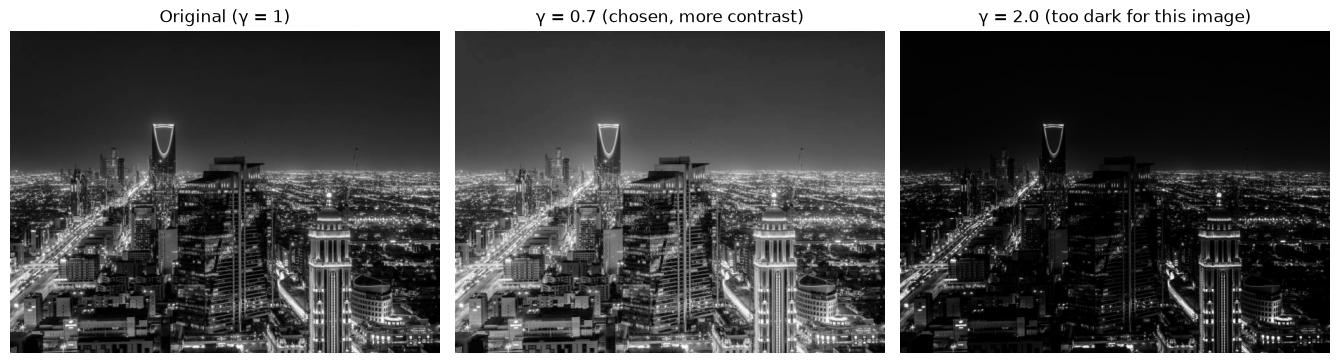

In [17]:
gamma_img = gamma_transform(gray, best_gamma)
gamma_high = gamma_transform(gray, 2.0)

show([gray, gamma_img, gamma_high],
     ['Original (γ = 1)', f'γ = {best_gamma} (chosen, more contrast)', 'γ = 2.0 (too dark for this image)'])

### 2.4 Comparison: transformation curves, results, and histograms

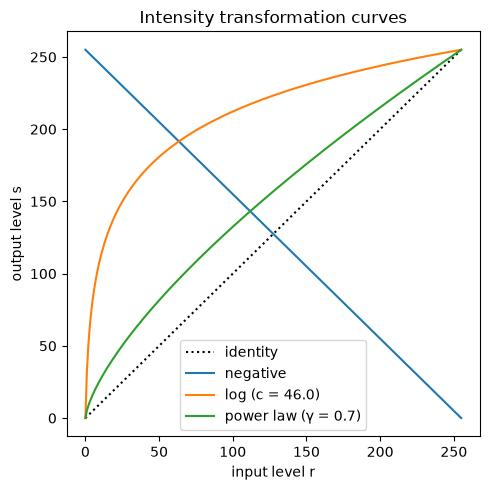

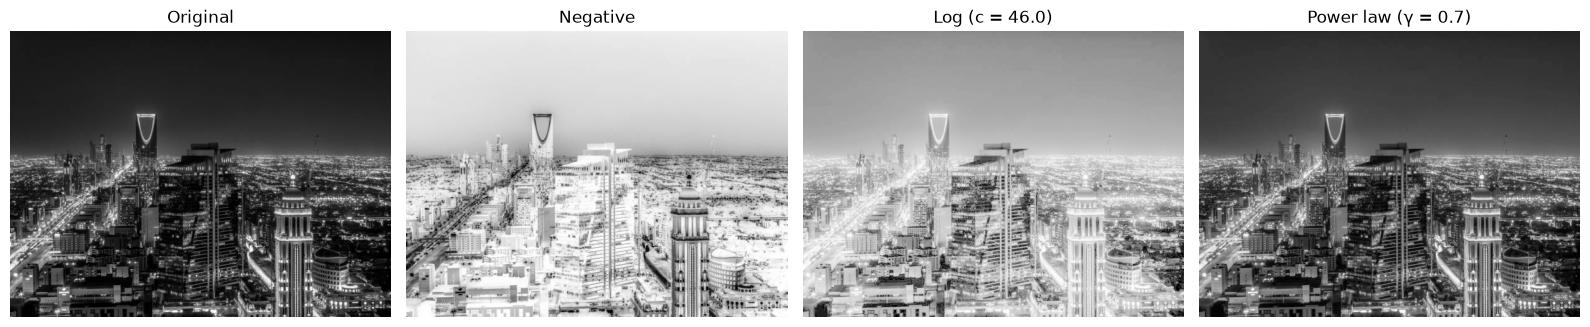

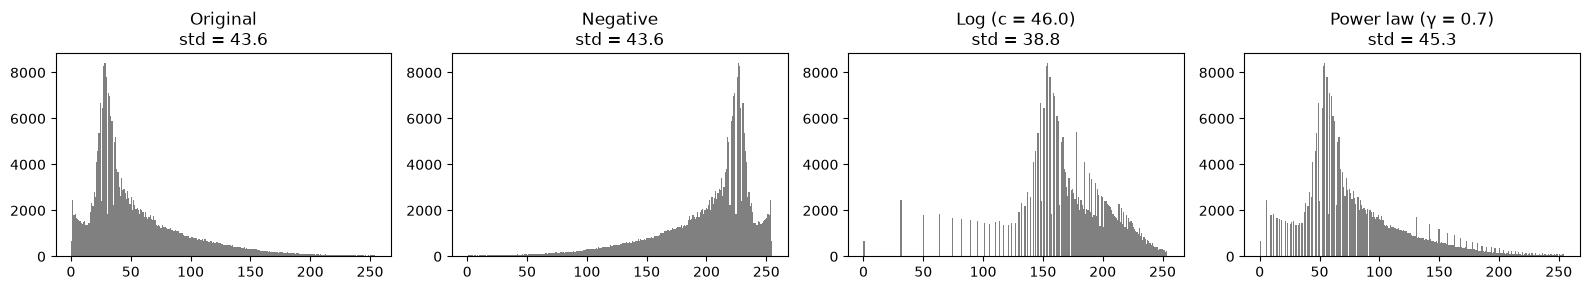

In [18]:
levels = np.arange(256)
plt.figure(figsize=(5, 5))
plt.plot(levels, levels, 'k:', label='identity')
plt.plot(levels, 255 - levels, label='negative')
plt.plot(levels, np.clip(c * np.log(1 + levels), 0, 255), label=f'log (c = {c:.1f})')
plt.plot(levels, 255 * (levels / 255) ** best_gamma, label=f'power law (γ = {best_gamma})')
plt.xlabel('input level r'); plt.ylabel('output level s')
plt.title('Intensity transformation curves'); plt.legend()
plt.tight_layout(); plt.show()

results = [gray, negative, log_img, gamma_img]
names = ['Original', 'Negative', f'Log (c = {c:.1f})', f'Power law (γ = {best_gamma})']
show(results, names, size=4)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, im, name in zip(axes, results, names):
    ax.hist(im.ravel(), bins=256, range=(0, 255), color='gray')
    ax.set_title(f'{name}\nstd = {im.std():.1f}')
plt.tight_layout(); plt.show()

## Summary

**Steps 1–4**
- OpenCV loads an image as a NumPy `uint8` array: `(rows, cols, 3)` in **BGR** order for color, `(rows, cols)` for grayscale.
- Grayscale can be applied while reading (`IMREAD_GRAYSCALE`) or afterwards (`cvtColor`). `imwrite` saves images to disk.
- `cvtColor` supports many color spaces. In **YUV**, Y is the brightness and U/V hold the blue/red color information.

**Task 1: Geometric transformations** (pixels move, values stay the same)
- **Scaling ×2** with `cv2.resize`. Bicubic interpolation gives a smoother result than nearest-neighbour.
- **Rotation by 120°** with `getRotationMatrix2D` + `warpAffine`. The output canvas has to be enlarged to keep the corners.
- **Shear** with an affine matrix that has an off-diagonal factor (horizontal $sh_x = 0.4$, vertical $sh_y = 0.3$).

**Task 2: Intensity transformations** (values change, positions stay the same)
- **Negative** $s = 255 - r$ swaps dark and bright.
- **Log** $s = c\log(1+r)$ with $c = 255/\log(1+r_{max})$ brightens the dark scene and uses the full 0–255 range. It reveals dark detail but compresses the bright lights, so the overall contrast drops slightly.
- **Power law** $s = 255(r/255)^\gamma$: because the image is dark, a $\gamma < 1$ was chosen by testing several values and keeping the one with the highest contrast (standard deviation). The best was γ = 0.7, and $\gamma > 1$ made this image even darker and reduced its contrast.